# Cross-Corpus Evaluation: ParkCeleb Model → KCL Dataset

The Random Forest model was trained on ParkCeleb celebrity speech (YouTube interviews).  
Here we evaluate it on the completely unseen KCL clinical dataset (controlled recordings).

This is a **cross-corpus evaluation** — the gold standard for showing a model generalises  
beyond its training data. We test on ReadText and SpontaneousDialogue separately.

---

In [14]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CHANGE THESE PATHS                                        ║
# ╚══════════════════════════════════════════════════════════════╝

# CYMO results from KCL (after uploading to CYMO and getting results back)
#CYMO_READTEXT  = '../KCL/ann.cymo_kcl_readtext.csv'
#CYMO_DIALOGUE  = '../KCL/ann.cymo_kcl_dialogue.csv'
CYMO_READTEXT  = '../KCL/ann.cymo_kcl_readtext_full.csv'
CYMO_DIALOGUE  = '../KCL/ann.cymo_kcl_dialogue_full.csv'

# Metadata from the converter script
#META_READTEXT  = './cymo_kcl_readtext_metadata.csv'
#META_DIALOGUE  = './cymo_kcl_dialogue_metadata.csv'
META_READTEXT  = './cymo_kcl_readtext_full_metadata.csv'
META_DIALOGUE  = './cymo_kcl_dialogue_full_metadata.csv'

# Trained model from ParkCeleb
#MODEL_PATH     = './rf_mrmr.joblib'
MODEL_PATH     = './rf_mrmr_cv.joblib'
#MODEL_PATH     = './svm_best.joblib'
#MODEL_PATH     = './gb_best.joblib'
#MODEL_PATH     = './rf_best_generalising.joblib'
#MODEL_PATH     = './rf_multimodal.joblib'
#MODEL_PATH     = './logreg_mrmr.joblib'

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.titleweight': 'bold'})
print('Imports OK')

Imports OK


In [16]:
# ============================================================
# 1.  Load the trained ParkCeleb model
# ============================================================
saved = joblib.load(MODEL_PATH)
model   = saved['model']
scaler  = saved['scaler']
features = saved['features']

print(f'Loaded model: {MODEL_PATH}')
print(f'  Type     : {type(model).__name__}')
print(f'  Features : {len(features)}')
print(f'  Trained on ParkCeleb (never seen KCL data)')

Loaded model: ./rf_mrmr_cv.joblib
  Type     : RandomForestClassifier
  Features : 24
  Trained on ParkCeleb (never seen KCL data)


In [17]:
# ============================================================
# 2.  Helper functions
# ============================================================

def load_and_merge(cymo_path, meta_path):
    """Load CYMO results and merge with metadata."""
    cymo = pd.read_csv(cymo_path)
    meta = pd.read_csv(meta_path)
    
    tid_col = 'TID' if 'TID' in cymo.columns else cymo.columns[0]
    meta_tid = 'TID' if 'TID' in meta.columns else meta.columns[0]
    
    df = cymo.merge(
        meta[[meta_tid, 'group', 'subject_id', 'hy_score',
              'updrs_ii_5', 'updrs_iii_18', 'source_file']].drop_duplicates(),
        left_on=tid_col, right_on=meta_tid, how='inner'
    )
    df['label'] = (df['group'] == 'PD').astype(int)
    
    # Convert feature columns to numeric
    feat_cols = [c for c in cymo.columns if c != tid_col]
    for col in feat_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    return df


def predict_and_evaluate(df, model, scaler, features, task_name):
    """
    Run the ParkCeleb model on KCL data.
    Returns subject-level results DataFrame and metrics dict.
    """
    # Check which features are available
    available = [f for f in features if f in df.columns]
    missing = [f for f in features if f not in df.columns]
    
    if missing:
        print(f'  WARNING: {len(missing)} features not in CYMO output, filling with 0:')
        for mf in missing[:5]:
            print(f'    — {mf}')
        if len(missing) > 5:
            print(f'    ... and {len(missing)-5} more')
        for mf in missing:
            df[mf] = 0.0
    
    # Prepare features
    X = df[features].fillna(0).values
    X_scaled = scaler.transform(X)
    y_true = df['label'].values
    
    # Predict
    y_pred = model.predict(X_scaled)
    y_prob = model.predict_proba(X_scaled)[:, 1]
    
    df = df.copy()
    df['pred'] = y_pred
    df['prob'] = y_prob
    
    # Subject-level majority vote
    subj = df.groupby('subject_id').agg(
        true_label=('label', 'first'),
        group=('group', 'first'),
        mean_prob=('prob', 'mean'),
        vote_pred=('pred', lambda x: int(x.mean() >= 0.5)),
        n_segments=('pred', 'count'),
        pct_pd=('pred', 'mean'),
        hy_score=('hy_score', 'first'),
        updrs_ii_5=('updrs_ii_5', 'first'),
        updrs_iii_18=('updrs_iii_18', 'first'),
    ).reset_index()
    
    # Metrics
    metrics = {
        'task': task_name,
        'n_subjects': len(subj),
        'n_segments': len(df),
        'acc': accuracy_score(subj['true_label'], subj['vote_pred']),
        'f1': f1_score(subj['true_label'], subj['vote_pred'], zero_division=0),
        'sens': recall_score(subj['true_label'], subj['vote_pred'], zero_division=0),
        'spec': recall_score(subj['true_label'], subj['vote_pred'], pos_label=0, zero_division=0),
        'auc': roc_auc_score(subj['true_label'], subj['mean_prob']) if subj['true_label'].nunique() > 1 else 0,
    }
    
    # Utterance-level metrics
    metrics['utt_acc'] = accuracy_score(y_true, y_pred)
    metrics['utt_auc'] = roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else 0
    
    return subj, metrics, df

---
## 3 — Run predictions on both KCL tasks

In [18]:
# ============================================================
# 3.1  ReadText
# ============================================================
print('Loading ReadText CYMO results...')
df_rt = load_and_merge(CYMO_READTEXT, META_READTEXT)
print(f'  {len(df_rt)} segments, {df_rt["subject_id"].nunique()} subjects\n')

subj_rt, metrics_rt, df_rt_pred = predict_and_evaluate(
    df_rt, model, scaler, features, 'ReadText'
)

Loading ReadText CYMO results...
  183 segments, 37 subjects



In [19]:
# ============================================================
# 3.2  SpontaneousDialogue
# ============================================================
print('Loading Dialogue CYMO results...')
df_sd = load_and_merge(CYMO_DIALOGUE, META_DIALOGUE)
print(f'  {len(df_sd)} segments, {df_sd["subject_id"].nunique()} subjects\n')

subj_sd, metrics_sd, df_sd_pred = predict_and_evaluate(
    df_sd, model, scaler, features, 'SpontaneousDialogue'
)

Loading Dialogue CYMO results...
  573 segments, 36 subjects



---
## 4 — Results

In [20]:
# ============================================================
# 4.1  Summary table
# ============================================================
print('CROSS-CORPUS EVALUATION: ParkCeleb RF mRMR → KCL Dataset')
print('=' * 75)
print(f'  Model trained on : ParkCeleb (celebrity YouTube interviews)')
print(f'  Model tested on  : KCL (clinical phone recordings)')
print(f'  Feature set      : mRMR ({len(features)} CYMO linguistic features)')
print(f'  Evaluation level : Subject-level majority vote')

print(f'\n{"Task":<25s} {"Subj":>6s} {"Acc":>7s} {"F1":>7s} {"AUC":>7s} {"Sens":>7s} {"Spec":>7s}')
print('─' * 65)
for m in [metrics_rt, metrics_sd]:
    print(f'{m["task"]:<25s} {m["n_subjects"]:>6d} {m["acc"]:>7.3f} {m["f1"]:>7.3f} '
          f'{m["auc"]:>7.3f} {m["sens"]:>7.3f} {m["spec"]:>7.3f}')

# Combined (treat both tasks as one pool)
subj_combined = pd.concat([subj_rt, subj_sd]).groupby('subject_id').agg(
    true_label=('true_label', 'first'),
    mean_prob=('mean_prob', 'mean'),
    vote_pred=('vote_pred', lambda x: int(x.mean() >= 0.5)),
).reset_index()
comb_acc = accuracy_score(subj_combined['true_label'], subj_combined['vote_pred'])
comb_auc = roc_auc_score(subj_combined['true_label'], subj_combined['mean_prob'])
comb_f1 = f1_score(subj_combined['true_label'], subj_combined['vote_pred'], zero_division=0)
comb_sens = recall_score(subj_combined['true_label'], subj_combined['vote_pred'], zero_division=0)
comb_spec = recall_score(subj_combined['true_label'], subj_combined['vote_pred'], pos_label=0, zero_division=0)
print(f'{"Combined (both tasks)":<25s} {subj_combined["subject_id"].nunique():>6d} '
      f'{comb_acc:>7.3f} {comb_f1:>7.3f} {comb_auc:>7.3f} {comb_sens:>7.3f} {comb_spec:>7.3f}')

CROSS-CORPUS EVALUATION: ParkCeleb RF mRMR → KCL Dataset
  Model trained on : ParkCeleb (celebrity YouTube interviews)
  Model tested on  : KCL (clinical phone recordings)
  Feature set      : mRMR (24 CYMO linguistic features)
  Evaluation level : Subject-level majority vote

Task                        Subj     Acc      F1     AUC    Sens    Spec
─────────────────────────────────────────────────────────────────
ReadText                      37   0.595   0.348   0.600   0.250   0.857
SpontaneousDialogue           36   0.694   0.560   0.683   0.467   0.857
Combined (both tasks)         38   0.711   0.645   0.733   0.625   0.773


In [21]:
# ============================================================
# 4.2  Per-subject detail tables
# ============================================================
for task_name, subj_df in [('ReadText', subj_rt), ('SpontaneousDialogue', subj_sd)]:
    print(f'\n{task_name} — Per-Subject Detail')
    print(f'{"Subject":<10s} {"True":>5s} {"Pred":>5s} {"OK":>3s} {"P(PD)":>7s} {"Segs":>5s} '
          f'{"%PD":>5s} {"H&Y":>4s} {"UII":>4s} {"UIII":>5s}')
    print('─' * 62)
    
    for _, row in subj_df.sort_values('subject_id').iterrows():
        true = 'PD' if row['true_label'] == 1 else 'CN'
        pred = 'PD' if row['vote_pred'] == 1 else 'CN'
        ok = '✓' if true == pred else '✗'
        hy = str(row['hy_score']) if pd.notna(row['hy_score']) else '-'
        u2 = str(row['updrs_ii_5']) if pd.notna(row['updrs_ii_5']) else '-'
        u3 = str(row['updrs_iii_18']) if pd.notna(row['updrs_iii_18']) else '-'
        print(f'{row["subject_id"]:<10s} {true:>5s} {pred:>5s} {ok:>3s} '
              f'{row["mean_prob"]:>7.3f} {row["n_segments"]:>5.0f} {row["pct_pd"]:>4.0%} '
              f'{hy:>4s} {u2:>4s} {u3:>5s}')


ReadText — Per-Subject Detail
Subject     True  Pred  OK   P(PD)  Segs   %PD  H&Y  UII  UIII
──────────────────────────────────────────────────────────────
ID00          CN    CN   ✓   0.316     4   0%    0    0     0
ID01          CN    CN   ✓   0.365     1   0%    0    0     0
ID02          PD    CN   ✗   0.365     1   0%    2    0     0
ID03          CN    CN   ✓   0.298    13   0%    0    0     0
ID04          PD    PD   ✓   0.528     4 100%    2    0     1
ID05          CN    CN   ✓   0.306     7   0%    0    0     0
ID06          PD    CN   ✗   0.409     2   0%    3    1     1
ID07          PD    CN   ✗   0.368     1   0%    2    0     0
ID08          CN    CN   ✓   0.325     4   0%    0    0     0
ID09          CN    CN   ✓   0.326     7   0%    0    0     0
ID10          CN    CN   ✓   0.266     7   0%    0    0     0
ID11          CN    CN   ✓   0.264     8   0%    0    0     0
ID12          CN    PD   ✗   0.509     3  67%    0    0     0
ID13          PD    CN   ✗   0.295   

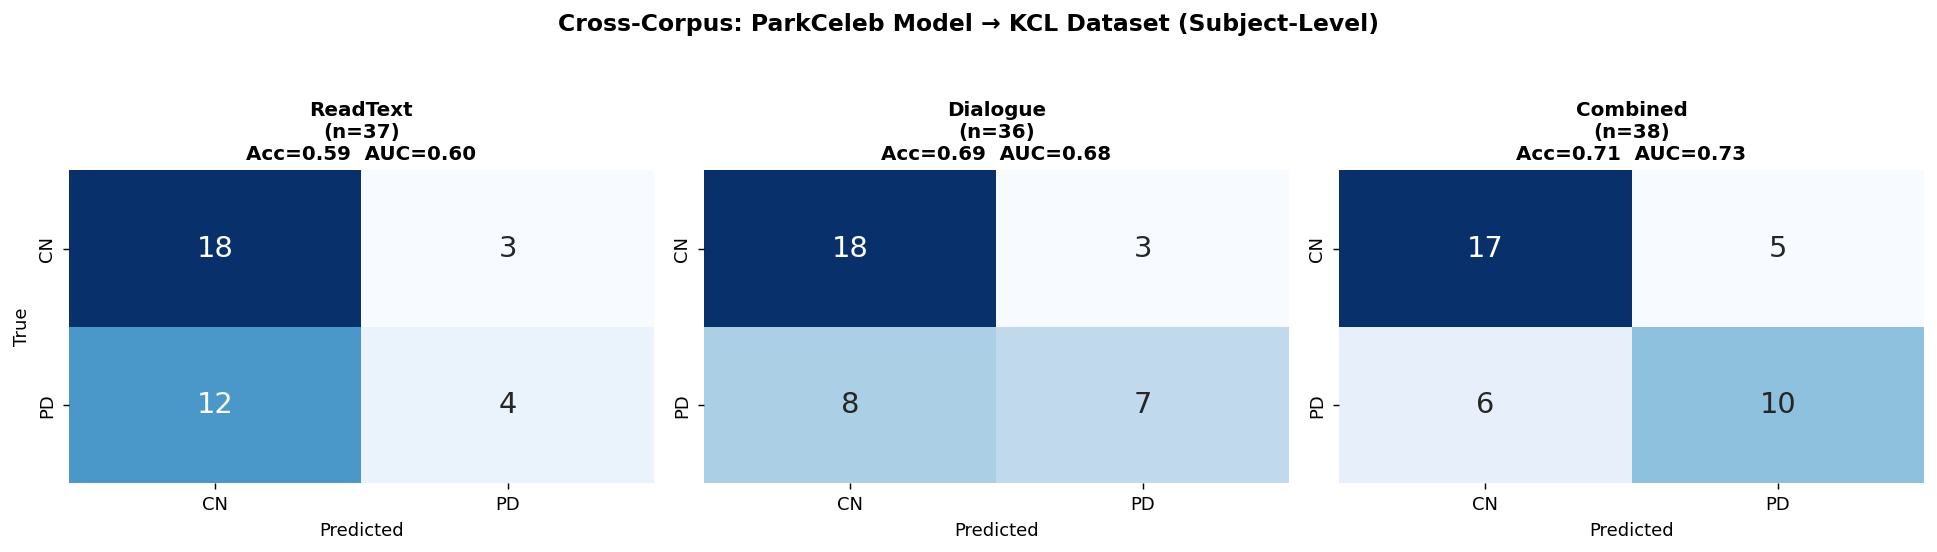

In [22]:
# ============================================================
# 4.3  Confusion matrices
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, subj_df, title in [
    (axes[0], subj_rt, f'ReadText\n(n={len(subj_rt)})'),
    (axes[1], subj_sd, f'Dialogue\n(n={len(subj_sd)})'),
    (axes[2], subj_combined, f'Combined\n(n={len(subj_combined)})'),
]:
    cm = confusion_matrix(subj_df['true_label'], subj_df['vote_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['CN', 'PD'], yticklabels=['CN', 'PD'],
                cbar=False, annot_kws={'size': 16})
    acc = accuracy_score(subj_df['true_label'], subj_df['vote_pred'])
    auc_val = roc_auc_score(subj_df['true_label'], subj_df['mean_prob'])
    ax.set_title(f'{title}\nAcc={acc:.2f}  AUC={auc_val:.2f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True' if ax == axes[0] else '')

plt.suptitle('Cross-Corpus: ParkCeleb Model → KCL Dataset (Subject-Level)',
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('cross_corpus_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

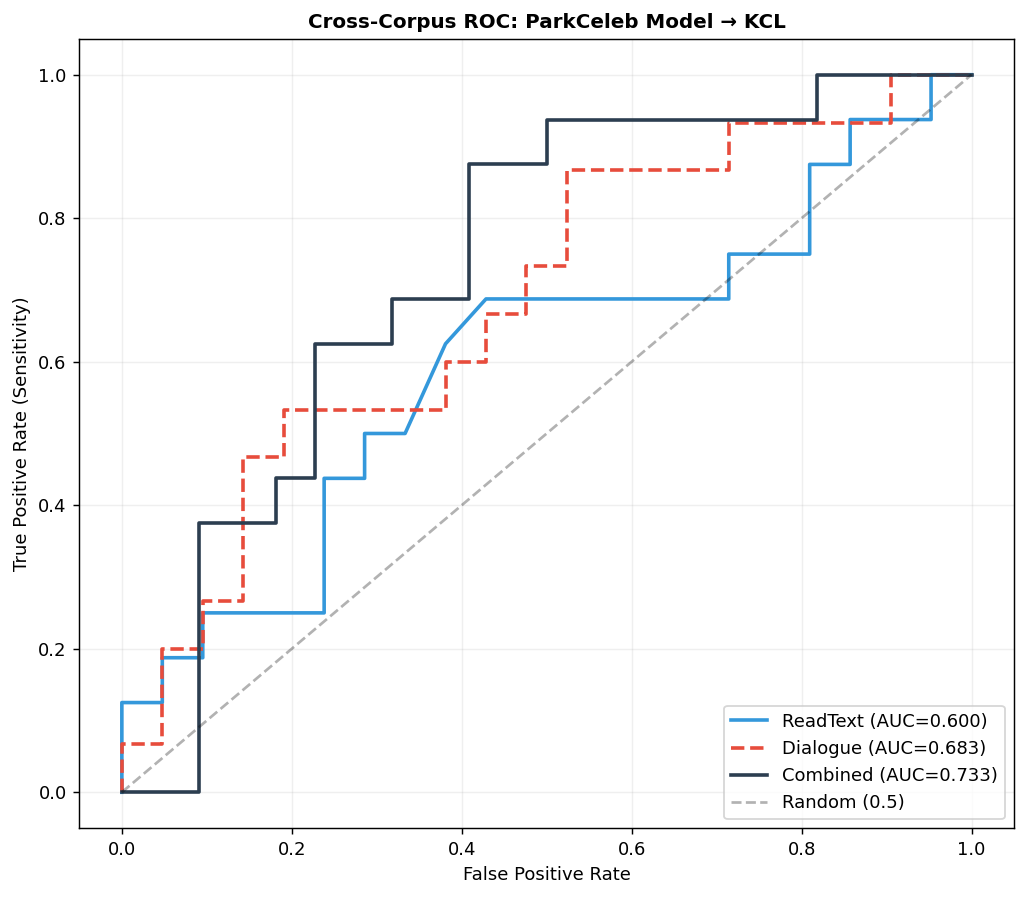

In [23]:
# ============================================================
# 4.4  ROC curves
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

for subj_df, label, color, ls in [
    (subj_rt, 'ReadText', '#3498DB', '-'),
    (subj_sd, 'Dialogue', '#E74C3C', '--'),
    (subj_combined, 'Combined', '#2C3E50', '-'),
]:
    fpr, tpr, _ = roc_curve(subj_df['true_label'], subj_df['mean_prob'])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linestyle=ls, linewidth=2,
            label=f'{label} (AUC={roc_auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random (0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('Cross-Corpus ROC: ParkCeleb Model → KCL')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('cross_corpus_roc.png', dpi=150, bbox_inches='tight')
plt.show()

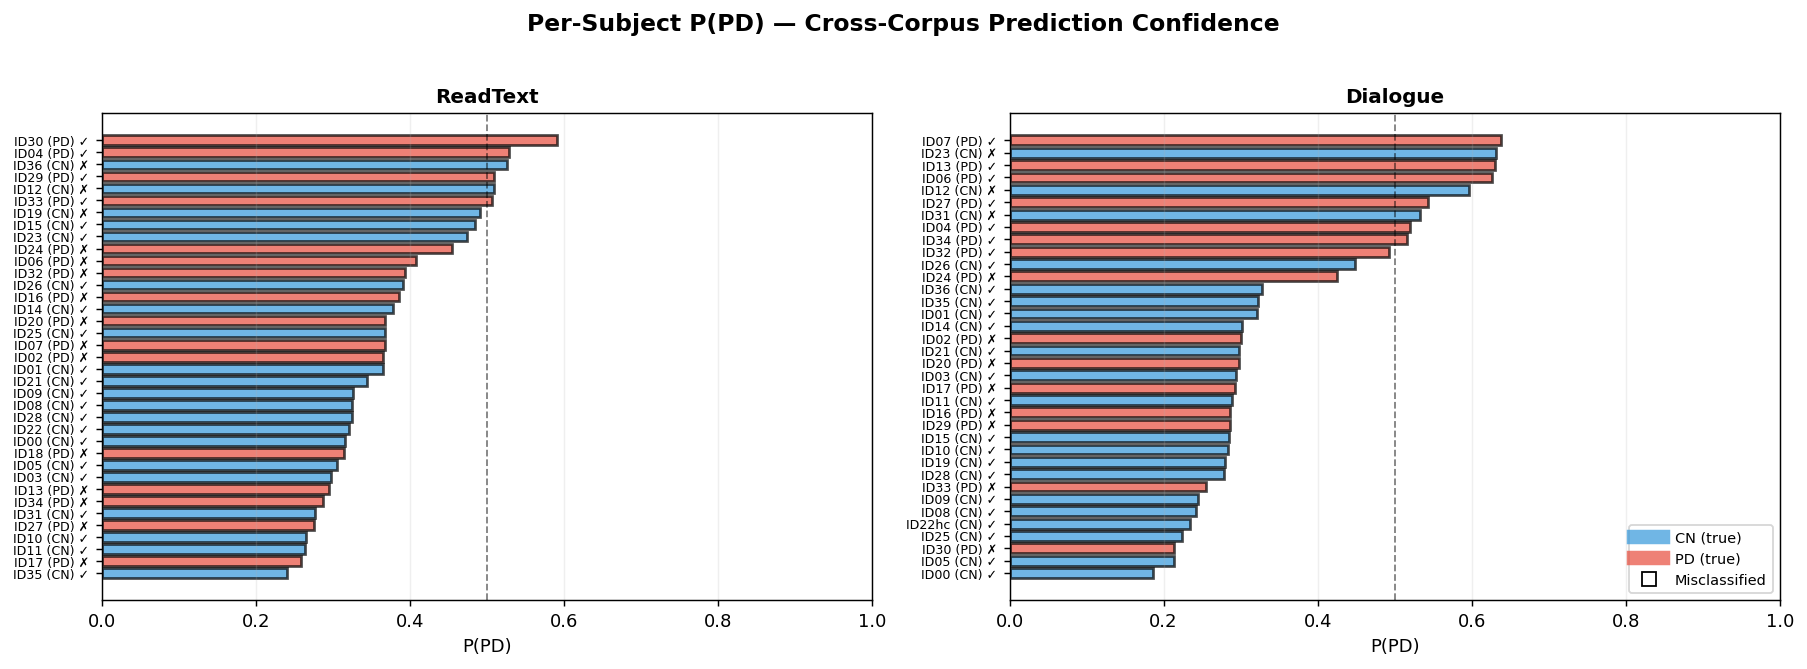

In [24]:
# ============================================================
# 4.5  Per-subject prediction confidence
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, subj_df, title in [
    (axes[0], subj_rt, 'ReadText'),
    (axes[1], subj_sd, 'Dialogue'),
]:
    subj_sorted = subj_df.sort_values('mean_prob')
    
    colors = ['#3498DB' if r['true_label'] == 0 else '#E74C3C'
              for _, r in subj_sorted.iterrows()]
    edge_colors = ['black' if r['true_label'] != r['vote_pred'] else 'none'
                   for _, r in subj_sorted.iterrows()]
    
    y_pos = range(len(subj_sorted))
    ax.barh(y_pos, subj_sorted['mean_prob'], color=colors,
            alpha=0.7, edgecolor=edge_colors, linewidth=1.5)
    ax.axvline(0.5, color='black', ls='--', lw=1, alpha=0.5, label='Decision boundary')
    
    ax.set_yticks(y_pos)
    labels = []
    for _, r in subj_sorted.iterrows():
        correct = '✓' if r['true_label'] == r['vote_pred'] else '✗'
        labels.append(f"{r['subject_id']} ({r['group']}) {correct}")
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel('P(PD)')
    ax.set_title(f'{title}')
    ax.set_xlim(0, 1)
    ax.grid(axis='x', alpha=0.2)

cn_patch = plt.Line2D([0], [0], color='#3498DB', lw=8, alpha=0.7, label='CN (true)')
pd_patch = plt.Line2D([0], [0], color='#E74C3C', lw=8, alpha=0.7, label='PD (true)')
wrong_patch = plt.Line2D([0], [0], color='white', markeredgecolor='black',
                          marker='s', markersize=8, lw=0, label='Misclassified')
axes[1].legend(handles=[cn_patch, pd_patch, wrong_patch], fontsize=8, loc='lower right')

plt.suptitle('Per-Subject P(PD) — Cross-Corpus Prediction Confidence',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('cross_corpus_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# ============================================================
# 4.6  Comparison with ParkCeleb performance
# ============================================================
print('\nPERFORMANCE COMPARISON')
print('=' * 70)
print(f'{"Dataset":<30s} {"Acc":>7s} {"F1":>7s} {"AUC":>7s} {"Sens":>7s} {"Spec":>7s}')
print('─' * 65)

# ParkCeleb results (from your RF notebook — update these with your actual numbers)
print(f'{"KCL ReadText":<30s} {metrics_rt["acc"]:>7.3f} {metrics_rt["f1"]:>7.3f} '
      f'{metrics_rt["auc"]:>7.3f} {metrics_rt["sens"]:>7.3f} {metrics_rt["spec"]:>7.3f}')
print(f'{"KCL Dialogue":<30s} {metrics_sd["acc"]:>7.3f} {metrics_sd["f1"]:>7.3f} '
      f'{metrics_sd["auc"]:>7.3f} {metrics_sd["sens"]:>7.3f} {metrics_sd["spec"]:>7.3f}')
print(f'{"KCL Combined":<30s} {comb_acc:>7.3f} {comb_f1:>7.3f} '
      f'{comb_auc:>7.3f} {comb_sens:>7.3f} {comb_spec:>7.3f}')

print(f'\nInterpretation:')
print(f'  If KCL accuracy is close to ParkCeleb → model generalises well across domains.')
print(f'  If KCL accuracy drops significantly → model may be overfitting to ParkCeleb recording conditions.')
print(f'  If ReadText >> Dialogue → controlled speech is easier to classify (expected).')
print(f'  If Dialogue >> ReadText → spontaneous speech carries more diagnostic signal.')


PERFORMANCE COMPARISON
Dataset                            Acc      F1     AUC    Sens    Spec
─────────────────────────────────────────────────────────────────
KCL ReadText                     0.595   0.348   0.600   0.250   0.857
KCL Dialogue                     0.694   0.560   0.683   0.467   0.857
KCL Combined                     0.711   0.645   0.733   0.625   0.773

Interpretation:
  If KCL accuracy is close to ParkCeleb → model generalises well across domains.
  If KCL accuracy drops significantly → model may be overfitting to ParkCeleb recording conditions.
  If ReadText >> Dialogue → controlled speech is easier to classify (expected).
  If Dialogue >> ReadText → spontaneous speech carries more diagnostic signal.


---
## Summary

### What this evaluation shows
- **Cross-corpus generalisation:** Can a model trained on celebrity YouTube speech  
  detect PD in clinical phone recordings it has never seen?
- **Task comparison:** Does reading aloud vs spontaneous conversation  
  carry different amounts of diagnostic information?
- **Clinical relevance:** The KCL dataset has expert-scored UPDRS and H&Y ratings,  
  so you can also check if misclassifications correlate with disease severity.

### Context from the ParkCeleb paper
The paper's cross-corpora experiments (training on controlled lab speech,  
testing on ParkCeleb celebrity speech) achieved:
- 63% accuracy in the prodromal phase (6-10 years before diagnosis)
- 79% accuracy in early post-diagnosis (0-5 years after)
- 82% accuracy in late post-diagnosis (11-30 years after)

Your cross-corpus experiment goes the opposite direction  
(train on uncontrolled → test on controlled), which may actually perform  
better since clinical recordings are cleaner.